## Learned, Work

model_cfg = {

            "input_dim":    train_inputs.shape[2],

            "hidden_dim":   num_neuron,

            'output_dim':   train_inputs.shape[2],

            "alpha":        0.01,

            "learn_alpha":  False,

            "preact_noise": 0.1,

            "postact_noise":0.1}

In [1]:
from rtgym import RatatouGym
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
temp_reso, spat_reso = 100, 1 # Temp reso: 100ms; Spatial reso: 1cm
gym = RatatouGym(temporal_resolution=temp_reso, spatial_resolution=spat_reso)

R_out, R_in = 17, 10
gym.init_arena_map(shape="loop", outer_radius=R_out, inner_radius=R_in)

17 10 10


In [3]:
vel_mean, vel_std = 2, 2

n_channels = 100

behavior_profile = {
                    "name":                   "random_explore",
                    "type":                   "predefined",
                    "velocity_mean":          vel_mean,
                    "velocity_sd":            vel_std,
                    "random_drift_magnitude": 0.05,
                    "switch_direction_prob":  0.05,
                    "switch_velocity_prob":   0.1,
                    'avoid_boundary_dist': 60
                    }

sensory_profile = {
                   "wsm": {
                          "type":     "weak_sm_cell",
                          "n_cells":   n_channels,
                          "sigma":     15,
                          "magnitude": 4,
                          "normalize": True
                          },
                    }

# Set the sensory and behavior profiles
gym.set_sensory_from_profile(sensory_profile)
gym.set_behavior_from_profile(behavior_profile)

arena_map = gym.arena_map

In [4]:
def generate_circular_trajectories(arena_map, R_out, R_in,
                                    mean_vel, std_vel, # Angular veloity
                                    time_points=100, batch_size=1, visualize=True):
    import numpy as np
    from matplotlib import pyplot as plt
    
    dim = arena_map.shape[0]
    y_c, x_c = int(dim/2), int(dim/2)
    loop_width = R_out - R_in
    avg_R = (R_out + R_in) / 2
    edge = loop_width / 6

    # Initiate trajectories
    trajectories = np.zeros((batch_size, time_points, 2))
    displacements = np.zeros((batch_size, time_points, 2))
    hds = np.zeros((batch_size, time_points, 1))

    current_batch = 0
    while current_batch < batch_size:
        i = current_batch

        # Initial positions
        R_0 = np.random.uniform(R_in+edge, R_out-edge)
        theta_0 = np.random.uniform(0, 2*np.pi)

        # Angular velocity generation: omega(t)
        omega = np.random.normal(mean_vel, std_vel, time_points) / avg_R
        # Angular displacement: theta(t)
        theta = np.cumsum(omega) + theta_0

        # Insert variations
        delta_R = (edge/2) * np.sin(np.linspace(0, np.pi*4, time_points)) # Narrow the range of R to ensure not hitting the wall
        # Radial displacement: R(t)
        R = R_0 + delta_R

        # Simulate trajectory
        x_traj = x_c + R*np.cos(theta)
        y_traj = y_c + R*np.sin(theta)

        # Add noise
        x_traj += np.random.uniform(-1, 1, size=time_points)
        y_traj += np.random.uniform(-1, 1, size=time_points)

        # Ensure all sampled points are valid
        valid_mask = ( (0 <= x_traj) & (x_traj < dim) &
                       (0 <= y_traj) & (y_traj < dim) &
                       (arena_map[y_traj.astype(int), x_traj.astype(int)] == 0) )
        if np.all(valid_mask):
            # print(f"Trajectory {i+1} is valid.")

            trajectories[i, :, 0] = x_traj
            trajectories[i, :, 1] = y_traj
            # Generate displacements
            dx, dy = np.diff(x_traj), np.diff(y_traj)
            displacements[i, :len(x_traj)-1, 0] = dx
            displacements[i, :len(y_traj)-1, 1] = dy
            # Generate head directions
            hds[i, :len(x_traj)-1, 0] = np.arctan2(dy, dx)

            current_batch += 1
        else:
            pass

    # Visualize
    if visualize:
        plt.figure(figsize=(6, 6))
        plt.imshow(arena_map, cmap="gray_r", origin="lower")  # 显示 arena
        for i in range(batch_size):
            plt.plot(trajectories[i, :, 0], trajectories[i, :, 1], label=f'Trajectory {i+1}')
        plt.scatter([x_c], [y_c], c='blue', marker='o', label="Center")  # 圆心
        plt.legend()
        plt.title("Circular Trajectories in Arena")
        plt.show()

    # Return trajectories data
    Traj = {'coords': trajectories, 'hds': hds, 'disps': displacements}

    return Traj

<class 'rtgym.trial.trial.Trajectory'>


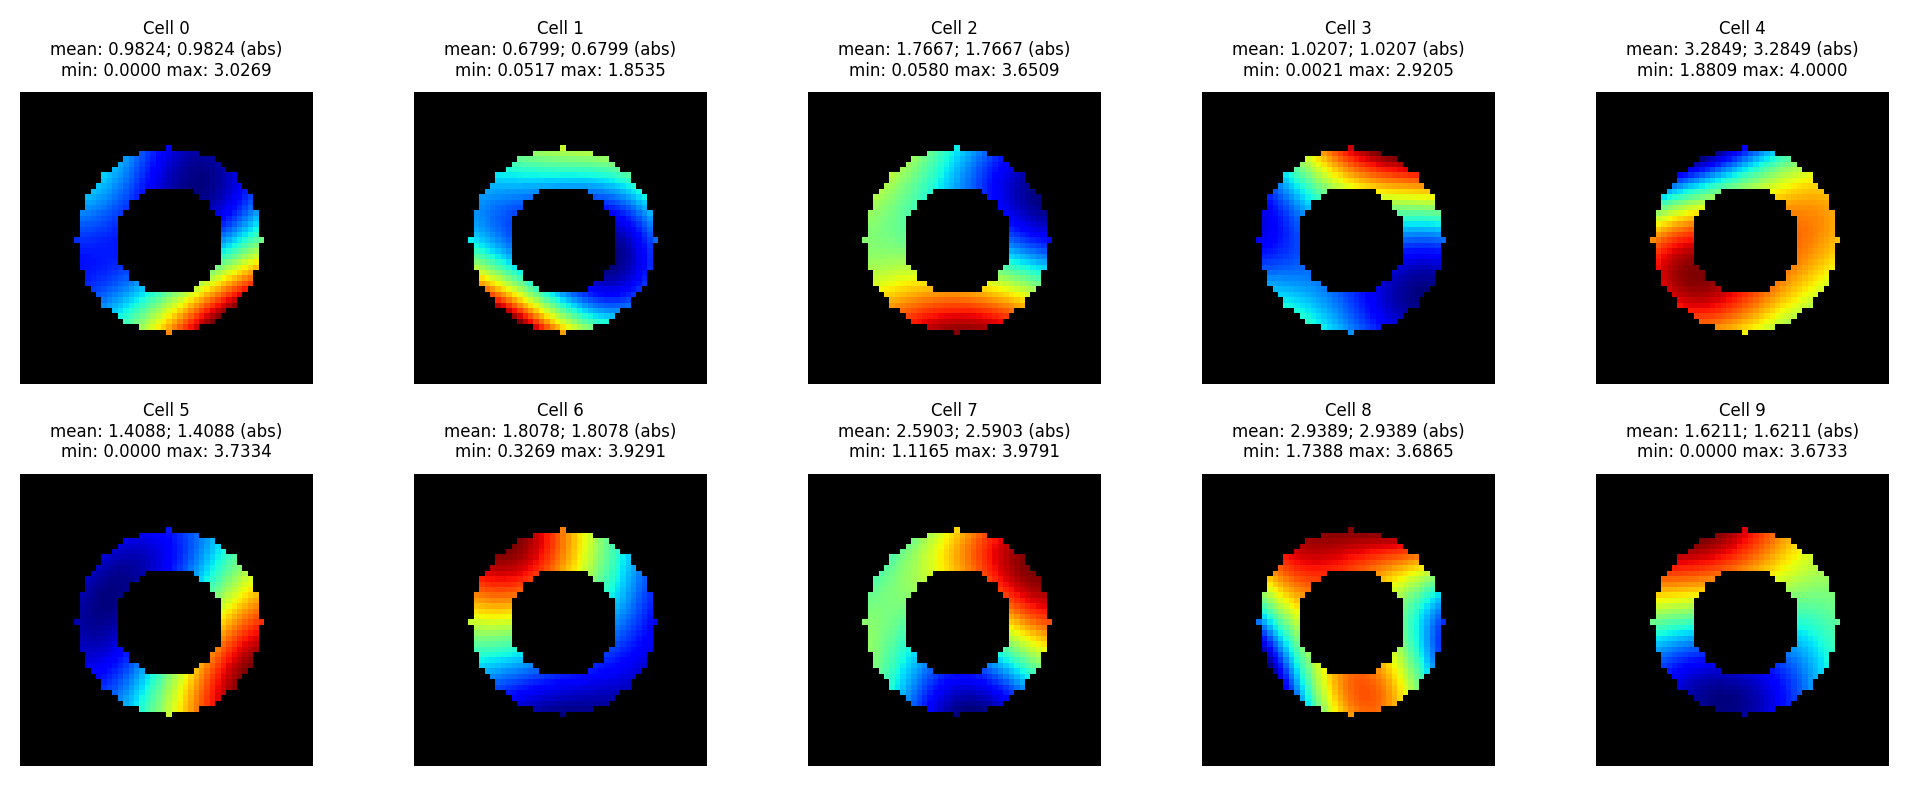

[(<Figure size 2000x800 with 10 Axes>,
  array([<Axes: title={'center': 'Cell 0\nmean: 0.9824; 0.9824 (abs)\nmin: 0.0000 max: 3.0269'}>,
         <Axes: title={'center': 'Cell 1\nmean: 0.6799; 0.6799 (abs)\nmin: 0.0517 max: 1.8535'}>,
         <Axes: title={'center': 'Cell 2\nmean: 1.7667; 1.7667 (abs)\nmin: 0.0580 max: 3.6509'}>,
         <Axes: title={'center': 'Cell 3\nmean: 1.0207; 1.0207 (abs)\nmin: 0.0021 max: 2.9205'}>,
         <Axes: title={'center': 'Cell 4\nmean: 3.2849; 3.2849 (abs)\nmin: 1.8809 max: 4.0000'}>,
         <Axes: title={'center': 'Cell 5\nmean: 1.4088; 1.4088 (abs)\nmin: 0.0000 max: 3.7334'}>,
         <Axes: title={'center': 'Cell 6\nmean: 1.8078; 1.8078 (abs)\nmin: 0.3269 max: 3.9291'}>,
         <Axes: title={'center': 'Cell 7\nmean: 2.5903; 2.5903 (abs)\nmin: 1.1165 max: 3.9791'}>,
         <Axes: title={'center': 'Cell 8\nmean: 2.9389; 2.9389 (abs)\nmin: 1.7388 max: 3.6865'}>,
         <Axes: title={'center': 'Cell 9\nmean: 1.6211; 1.6211 (abs)\nmin: 0.00

In [5]:
time_pts = 100
traj = generate_circular_trajectories(arena_map, R_out, R_in, vel_mean, vel_std,
                    time_points=time_pts, batch_size=1000, visualize=False)

# Generate (Batch size) trial
gym.trial.new_trial(duration=0, external_traj=traj)

gym.trial.vis_sensory()

In [6]:
space_res = gym.trial.get_responses(keys='wsm')
print('space responses:', space_res.shape)

space responses: (1000, 100, 100)


In [7]:
traj = gym.trial.get_traj()
traj['coords'] = traj['coords_float'] 
traj['hds'] = traj['head_directions']
traj['disps'] = traj['displacements']
del traj['coords_float']
del traj['head_directions']
del traj['displacements']
print(traj.keys())

dict_keys(['coords', 'hds', 'disps'])


Text(0, 0.5, 'Channels')

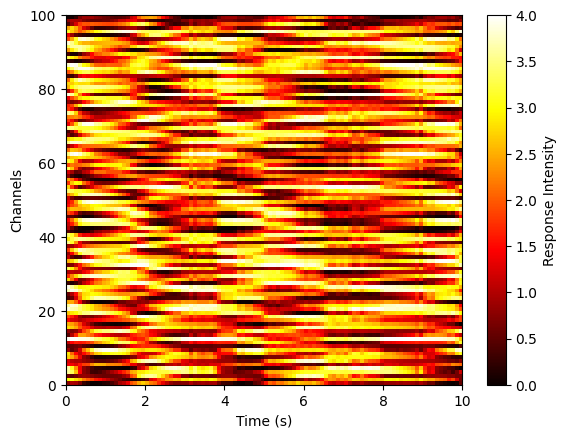

In [8]:
# Plot the space_res
plt.imshow(space_res[0].T, aspect='auto', cmap='hot', 
           extent=[0, space_res.shape[1]*temp_reso/1000, 0, n_channels])
plt.colorbar(label='Response Intensity')
plt.xlabel('Time (s)')
plt.ylabel('Channels')

In [9]:
labels = space_res.copy()

inputs = space_res.copy()
# Mask the inputs
from rtgym.utils.masking import Masking
mask = Masking(
                m_max=0.4,    # Maximum masking ratio
                m_min=0.2,    # Minimum masking ratio
                sigma_t=2.0,  # Temporal smoothing
                sigma_d=1.0,  # Spatial smoothing
                t_warmup=10,  # Number of initial time steps to remain unmasked
                # device=torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
                )
inputs = mask.mask(inputs).numpy()

Text(0, 0.5, 'Channels')

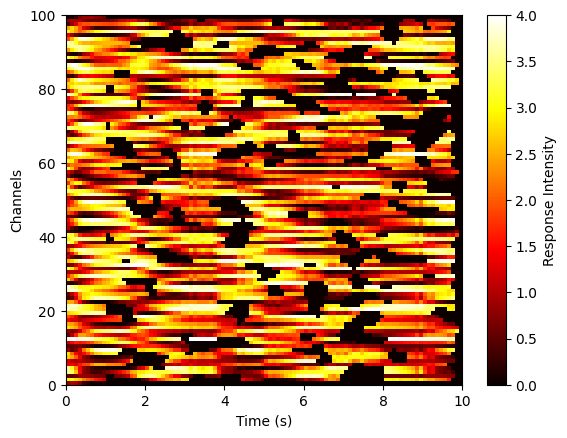

In [10]:
# Plot the masked inputs
plt.imshow(inputs[0].T, aspect='auto', cmap='hot', 
           extent=[0, inputs.shape[1]*temp_reso/1000, 0, n_channels])
plt.colorbar(label='Response Intensity')
plt.xlabel('Time (s)')
plt.ylabel('Channels')

In [11]:
# Split the data to training and test set along axis=1
from torch.utils.data import DataLoader, TensorDataset
import torch
import nn4n

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


indices = np.arange(inputs.shape[0])
train_inputs, test_inputs, train_labels, test_labels, train_indices, \
test_indices = train_test_split(inputs, labels, indices, test_size=0.05, random_state=42)

if isinstance(train_inputs, np.ndarray):
    train_inputs  = torch.from_numpy(train_inputs).float().to(device)
    train_labels  = torch.from_numpy(train_labels).float().to(device)
    test_inputs   = torch.from_numpy(test_inputs).float().to(device)
    test_labels   = torch.from_numpy(test_labels).float().to(device)

print('train_inputs:',  train_inputs.shape)
print('train_labels:',  train_labels.shape)
print('test_inputs:',   test_inputs.shape)
print('test_labels:',   test_labels.shape)
print('train_indices:', train_indices.shape)
print('test_indices:',  test_indices.shape)

train_dataset = TensorDataset(train_inputs, train_labels)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

Using device: cuda
train_inputs: torch.Size([950, 100, 100])
train_labels: torch.Size([950, 100, 100])
test_inputs: torch.Size([50, 100, 100])
test_labels: torch.Size([50, 100, 100])
train_indices: (950,)
test_indices: (50,)


In [12]:
num_neuron = 512

# custom_alpha = 1 - np.exp(-np.linspace(0.1, 5, num_neuron))

model_cfg = {
            "input_dim":    train_inputs.shape[2],
            "hidden_dim":   num_neuron,
            'output_dim':   train_inputs.shape[2],
            "alpha":        0.01,
            "learn_alpha":  False,
            "preact_noise": 0.1,
            "postact_noise":0.1
            }


rnn = nn4n.nn.RNN(
      # Input laters (multiple recurrent layers)
      recurrent_layers=[# 1st recurrent layer
                        nn4n.nn.RecurrentLayer(
                        projection_layer=nn4n.nn.LinearLayer(
                                         input_dim=model_cfg["input_dim"],
                                         output_dim=model_cfg["hidden_dim"]
                                         ),
                        leaky_layer=nn4n.nn.LeakyLinearLayer(
                                    # ----------------------------------------
                                    linear_layer=nn4n.nn.LinearLayer(
                                        input_dim=model_cfg["hidden_dim"],
                                        output_dim=model_cfg["hidden_dim"]),
                                    # ----------------------------------------
                                    activation=torch.nn.ReLU(),
                                    alpha=model_cfg["alpha"],
                                    learn_alpha=model_cfg["learn_alpha"],
                                    preact_noise=model_cfg["preact_noise"],
                                    postact_noise=model_cfg["postact_noise"]
                                    )
                        )
                        # 2nd recurrent layer (None)
                        ],
      # Output layer
      readout_layer=nn4n.nn.LinearLayer(
                    input_dim=model_cfg["hidden_dim"],
                    output_dim=model_cfg["output_dim"]
                    )
      )
rnn.to(device)


def custom_loss(recon, target, firing_rates, lambda_mse, lambda_r):
    """
    Args:
        recon: [batch, time, dim] — reconstructed experience vectors (ŷ)
        target: [batch, time, dim] — ground truth experience vectors (y)
        firing_rates: [batch, time, N] — firing rates of all hidden neurons
    """

    # Shape values
    B, T, D = target.shape
    N = firing_rates[0].shape[2]

    # 1. Reconstruction MSE Loss
    mse = torch.sum((recon - target) ** 2) / (B * T * D)
    # mse = torch.nn.MSELoss()
    # mse = mse(recon, target)

    # 2. Firing rate regularization term
    reg = torch.sum(torch.sum(firing_rates[0], axis=(0,1))**2 / (B * T)) / N

    total_loss = lambda_mse * mse + lambda_r * reg
    # print(lambda_mse * mse, lambda_r * reg)
    return total_loss, lambda_mse * mse, lambda_r * reg


optimizer = torch.optim.Adam(rnn.parameters(), lr=0.0005) 

In [13]:
from tqdm import tqdm

rnn.train()

losses = []

for epoch in tqdm(range(2000)):

    for batch_inputs, batch_labels in train_loader:
        
        optimizer.zero_grad()
        batch_outputs, batch_hidden = rnn(batch_inputs)
        
        # loss = criterion(batch_outputs, batch_labels)
        loss, loss1, loss2 = custom_loss(batch_outputs, batch_labels, batch_hidden, lambda_mse=1, lambda_r=0.0001
                           ) 
        loss.backward()
        
        optimizer.step()
        losses.append(loss.item())
        
    if epoch % 500 == 0:
        print(f'Epoch {epoch} Loss {loss.item()}')
        print(loss1, loss2)
    # if loss1 < 0.02:
    #     print("Early stopping due to low MSE loss.")
    #     break
    if  losses[-1] < 0.01 and abs(losses[-1] - losses[-50]) < 1e-4: # len(losses) > 50  :
        print("Early stopping due to convergence.")
        break
    
print("Training complete.")

  0%|          | 1/2000 [00:00<15:42,  2.12it/s]

Epoch 0 Loss 2.2179665565490723
tensor(2.0041, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.2139, device='cuda:0', grad_fn=<MulBackward0>)


 25%|██▌       | 501/2000 [02:24<07:09,  3.49it/s]

Epoch 500 Loss 0.091516874730587
tensor(0.0795, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0120, device='cuda:0', grad_fn=<MulBackward0>)


 50%|█████     | 1001/2000 [04:48<04:48,  3.47it/s]

Epoch 1000 Loss 0.05915314331650734
tensor(0.0514, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0077, device='cuda:0', grad_fn=<MulBackward0>)


 75%|███████▌  | 1501/2000 [07:11<02:23,  3.48it/s]

Epoch 1500 Loss 0.052534084767103195
tensor(0.0454, device='cuda:0', grad_fn=<MulBackward0>) tensor(0.0071, device='cuda:0', grad_fn=<MulBackward0>)


100%|██████████| 2000/2000 [09:35<00:00,  3.48it/s]

Training complete.


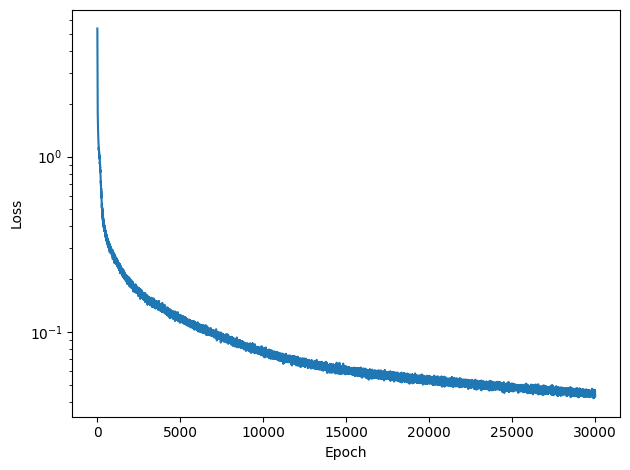

In [14]:
plt.figure()
plt.plot(losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')  
plt.tight_layout()

In [15]:
rnn.eval()
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(test_inputs)

test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
print('test outputs:',  type(test_outputs),  test_outputs.shape)
print('hidden states:', type(hidden_states), hidden_states.shape)

test outputs: <class 'numpy.ndarray'> (50, 100, 100)
hidden states: <class 'numpy.ndarray'> (50, 100, 512)


Text(0, 0.5, 'Channels')

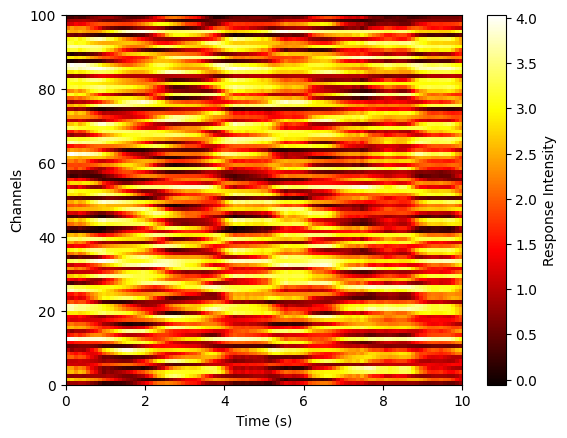

In [16]:
# Plot the masked inputs
plt.imshow(test_outputs[0].T, aspect='auto', cmap='hot', 
           extent=[0, test_outputs.shape[1]*temp_reso/1000, 0, n_channels])
plt.colorbar(label='Response Intensity')
plt.xlabel('Time (s)')
plt.ylabel('Channels')

In [17]:
def plt_hs(hs, min_fr=0.1, masks=None, fig=None, ax=None):

    time_points = hs.shape[0]

    # Select neurons with mean firing rate > 0.1
    mean_fr = hs.mean(axis=0)
    # Get the index where mean_fr > min_fr
    mask = mean_fr > min_fr
    neuron_indices = np.where(mask)[0]
    select_hs = hs[:, neuron_indices]
    del hs

    # Normalize the hs along time points (Sure to be correct!)
    # norm_hs = select_hs / np.linalg.norm(select_hs, axis=0, keepdims=True)
    # 0-1 Normalise method 2
    norm_hs = np.zeros_like(select_hs)
    for n in range(select_hs.shape[1]):
        norm_hs[:, n] = (select_hs[:, n]-np.min(select_hs[:, n]))/(np.max(select_hs[:, n])-np.min(select_hs[:, n]))
    del select_hs
    
    # Sort neurons from maximum firing time
    max_time = np.argmax(norm_hs, axis=0)
    sorted_neuron_indices = np.argsort(max_time)
    norm_hs = norm_hs[:, sorted_neuron_indices]
    num_neurons = norm_hs.shape[1]
    
    # Plot the normalized hs
    ax.imshow(norm_hs.T, aspect='auto', cmap='jet',  
              extent=[0, time_points/10, 0, num_neurons]
              )
    # ax.set_xlabel('Time (s)')
    ax.set_ylabel('Neurons')
    ax.set_xticks(np.linspace(0, norm_hs.shape[0]/10, 6))

    if masks is not None:
        for m in masks:
            ax.axvline(x=m[0], color='white', linestyle='--', linewidth=1)
            ax.axvline(x=m[1], color='white', linestyle='-', linewidth=1)
            # Plot a semi-transparent rectangle to cover the masked region
            ax.add_patch(plt.Rectangle((m[0], 0), m[1]-m[0], norm_hs.shape[1], 
                                       color='white', alpha=0.3))
    
    # # Plot the colorbar
    # cbar = fig.colorbar(ax.images[0], ax=ax)
    # cbar.set_label('Normalized firing rate')
    return norm_hs, fig, ax

(100, 512)
(100, 184)


Text(0.5, 0, 'Time (s)')

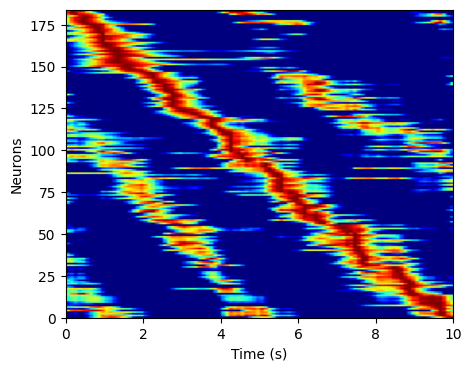

In [ ]:
# Plot the single batch
avg_hs = hidden_states[0]  
print(avg_hs.shape)

fig, ax = plt.subplots(figsize=(5, 4))
norm_hs, fig, ax = plt_hs(avg_hs, min_fr=0.1, fig=fig, ax=ax)
print(norm_hs.shape)
ax.set_xlabel('Time (s)')
# plt.savefig('2TS_1_hidden_states.png', dpi=500, transparent=True)

In [20]:
test_traj = {key: traj[key][test_indices] for key in traj.keys()}
train_traj = {key: traj[key][train_indices] for key in traj.keys()}

In [22]:
# Save the data
save_dict = {
            'train_inputs': train_inputs,
            'train_labels': train_labels,
            'test_inputs':  test_inputs,
            'test_labels':  test_labels,
            'test_outputs': test_outputs,
            'test_hidden_states': hidden_states,
            'train_traj': train_traj,
            'test_traj': test_traj,
        }
np.save('2WSMS_1_data.npy', save_dict)

In [23]:
# Save the model weights
torch.save(rnn.state_dict(), f'2WSMS_1_rnn.pth')